# Real-Time Gesture Typing - Model Training

This notebook is used for experimentation, including dataset exploration, preprocessing, data augmentation, and model training.

The final implementation of the project is organized in standalone Python scripts (`.py`), which use the trained model for real-time gesture recognition.

## Imports

In [55]:
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Import Dataset

In [78]:

# pasta base com subpastas A, B, C, ...
base_folder = "./data/asl_alphabet_train"

# dataset de treino (80%) e validação (20%)
batch_size = 64
img_size = [128, 128]

ds_train_ = tf.keras.utils.image_dataset_from_directory(
    base_folder,
    labels='inferred',          # labels vêm das subpastas
    label_mode='categorical',   # 29 classes → one-hot
    validation_split=0.2,       # 20% validação
    subset="training",
    seed=42,                    # para divisão reproducível
    image_size=img_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

ds_valid_ = tf.keras.utils.image_dataset_from_directory(
    base_folder,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 87000 files belonging to 29 classes.
Using 69600 files for training.
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.


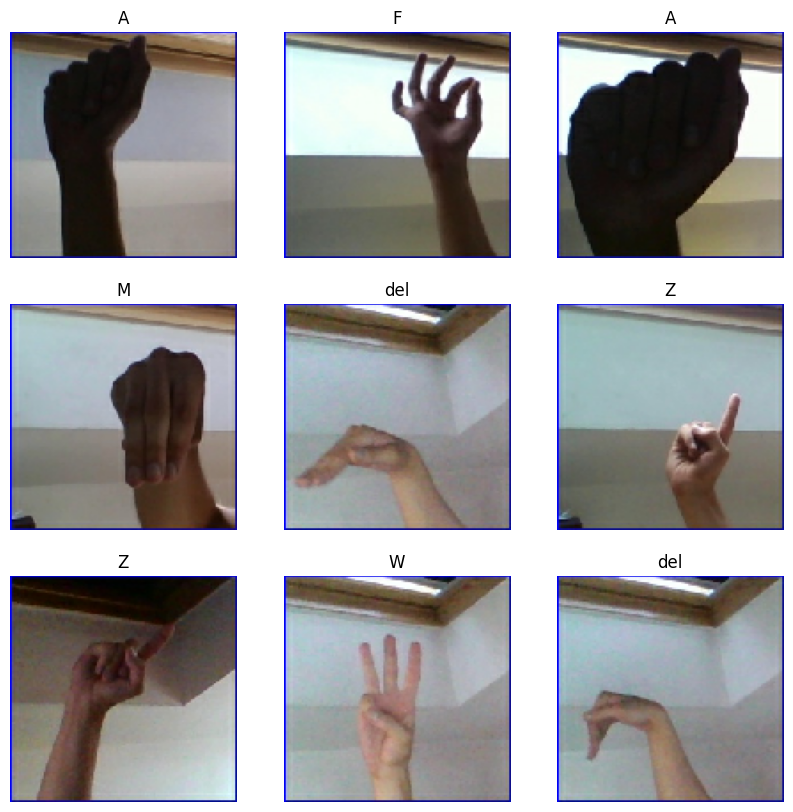

In [82]:
class_names = ds_train_.class_names  # lista de nomes das classes

for images, labels in ds_train.take(1):
    images = tf.clip_by_value(images, 0.0, 1.0)  # garante que matplotlib não queixa
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        label_index = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_index])  # mostra o nome da classe
        plt.axis("off")
    plt.show()
    break

## Data Augmentation

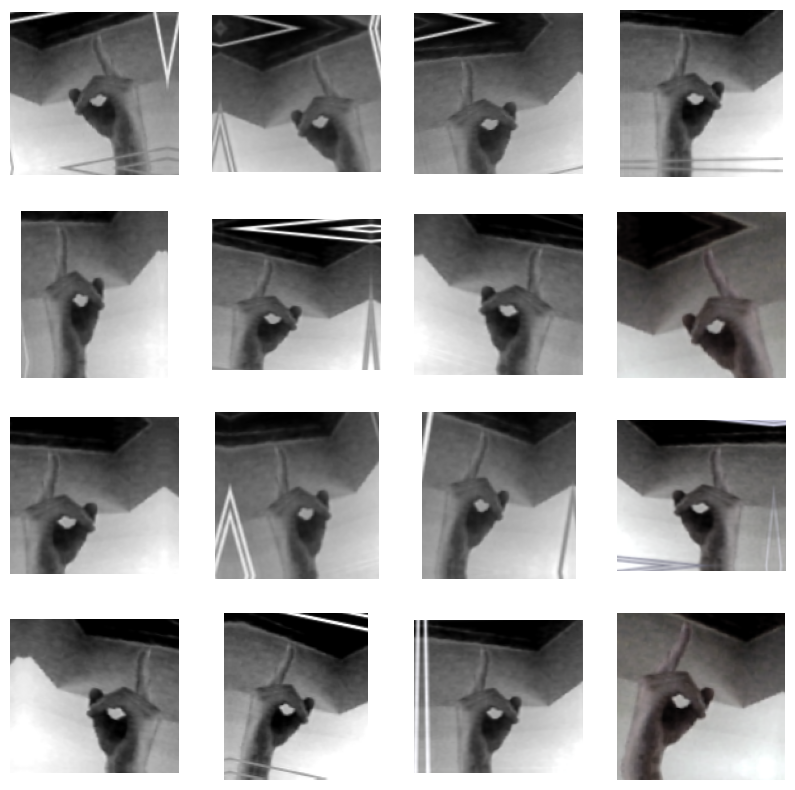

In [131]:
augment = keras.Sequential([
    layers.RandomContrast(factor=0.5),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    #layers.RandomBrightness(factor=0.1,),
    layers.RandomSaturation(factor=0.2),
    layers.RandomFlip(mode='horizontal'), # meaning, left-to-right
    #layers.RandomFlip(mode='vertical'), # meaning, top-to-bottom
    layers.RandomWidth(factor=0.15), # horizontal stretch
    layers.RandomRotation(factor=0.05),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])


ex = next(iter(ds_train.unbatch().map(lambda x, y: x).batch(1)))

plt.figure(figsize=(10,10))
for i in range(16):
    image = augment(ex, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)  # força 0..1
    plt.subplot(4, 4, i+1)
    plt.imshow(tf.squeeze(image))
    plt.axis('off')
plt.show()

## Model Layers

In [ ]:
model = keras.Sequential([
    layers.InputLayer(shape = [128, 128, 3]),

    #Data Augmentation
    

    #Layers of NN - Blocks

    #choose activation functions and kernel_size

    #Dense layers - Head

])